In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics


## Data Collection and Processing

In [5]:
# Loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO (2).csv')

In [6]:
# Inspecting the first 5 rows of the dataframe
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
car_dataset.shape

(4340, 8)

In [8]:
 # Getting some info about the dataset
 car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [9]:
# Checking the number of missing values
car_dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [10]:
print(car_dataset.fuel.value_counts())
print(car_dataset.seller_type.value_counts())
print(car_dataset.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


In [11]:
# encoding the categorical data
car_dataset.replace({'fuel':{'Petrol':0,'Diesel':1, 'CNG':2}}, inplace=True)

# encoding the categorical data
car_dataset.replace({'fuel':{'Dealer':0,'Individual':1}}, inplace=True)

# encoding the categorical data
car_dataset.replace({'transmission':{'Manual':0,'Automatic':1}}, inplace=True)

/tmp/ipython-input-2304079949.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'transmission':{'Manual':0,'Automatic':1}}, inplace=True)


In [13]:
X = car_dataset.drop(['name','selling_price'],axis=1)
Y = car_dataset['selling_price']

In [14]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


## Splitting Training and Test data

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

In [19]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


# Model Training

### 2. Linear Regression

In [20]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [21]:
lin_reg_model.fit(X_train,Y_train)

ValueError: could not convert string to float: 'LPG'

In [22]:
X_train.head()
X_train.dtypes


,0
year,int64
km_driven,int64
fuel,object
seller_type,object
transmission,int64
owner,object


In [23]:
import pandas as pd

# Convert categorical columns into dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure train and test have same columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


In [24]:
lin_reg_model.fit(X_train, Y_train)


LinearRegression()

# Model Evaluation

In [25]:
# prediction on training data
training_data_prediction = lin_reg_model.predict(X_train)

In [26]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error :", error_score)

R squared Error : 0.4510868454908873


## Visualize the actual prices and predicted prices

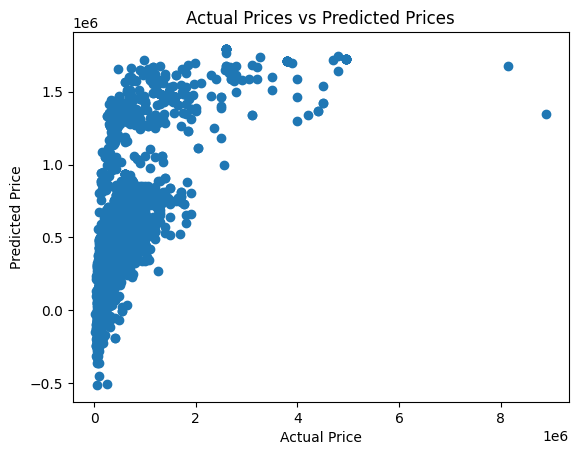

In [27]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [29]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [30]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.5304591679401967


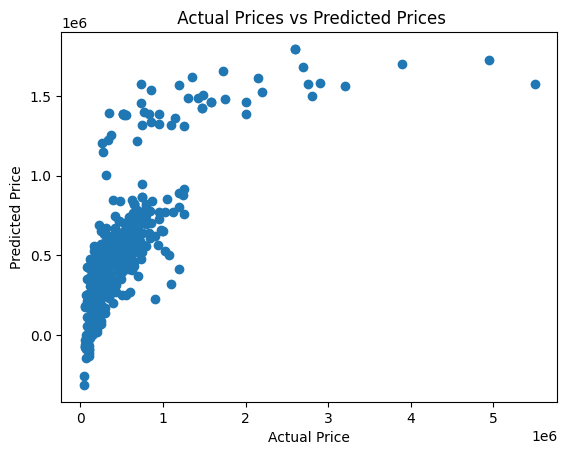

In [31]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()